# Vector และ Matrix สำหรับ Machine Learning — เรียนด้วย NumPy ทีละขั้น

**ระดับ:** เริ่มต้น • **เวลาประมาณ:** 90–120 นาที แบ่งเรียนได้ 3 รอบ • **ภาษา:** ไทย พร้อมศัพท์อังกฤษที่ใช้จริง

บทเรียนนี้ใช้ข้อมูลและภาพประกอบที่สร้างขึ้นใหม่ เพื่อเชื่อมคณิตศาสตร์กับโค้ด:
จากข้อมูลบ้านหนึ่งหลัง → ตารางข้อมูล → สมการทำนาย → การเรียนรู้จากข้อมูล → tensor ของภาพ
ไม่ได้แปลหรือคัดลอกบทความอ้างอิงทั้งฉบับ

**ก่อนเริ่ม:** รู้จักตัวแปร list, loop และ function ใน Python เลือก kernel `.venv` ของโครงการ
แล้วใช้ **Restart Kernel → Run All** โค้ดใช้เฉพาะแพ็กเกจที่มีในโครงการ ไม่ต้องดาวน์โหลดข้อมูล
รันตามลำดับ เพราะเซลล์ถัดไปใช้ตัวแปรจากเซลล์ก่อนหน้า ภาพจะถูกสร้างและแสดงภายใน notebook

เมื่อเรียนจบ คุณควรอธิบายได้ว่า:
1. `shape`, `ndim`, `size` และ `dtype` บอกอะไร
2. หนึ่งแถวของ `X` และหนึ่งคอลัมน์ของ `X` หมายถึงอะไร
3. `*` ต่างจาก `@` อย่างไร และตรวจขนาดก่อนคูณได้อย่างไร
4. dot product, norm, broadcasting และ transpose ช่วยในงาน ML อย่างไร
5. ใช้ matrix เพื่อทำนายหลายตัวอย่างพร้อมกัน และสร้างโมเดลเชิงเส้นอย่างง่ายได้

**เส้นทาง:** ส่วน 1–5 พื้นฐาน → ส่วน 6–10 การคำนวณ → ส่วน 11–15 use cases → ส่วน 16 แบบฝึกหัด

## 1. เตรียมเครื่องมือ

ใช้ `numpy.ndarray` เป็นโครงสร้างหลัก ไม่ใช้ `np.matrix` เพื่อให้การคำนวณหลายมิติเป็นรูปแบบเดียวกัน
`pandas` ใช้แสดงตาราง และ `matplotlib` ใช้วาดภาพ กำหนด seed เพื่อให้ข้อมูลสุ่มทำซ้ำได้

ชื่อในโค้ดใช้ภาษาอังกฤษเพื่ออ่านเอกสารต่อได้ง่าย คำอธิบายและคำถามเป็นภาษาไทย
กราฟจะใช้ฟอนต์ไทยที่ติดตั้งในเครื่อง หากไม่มีจะเปลี่ยนป้ายกราฟเป็นภาษาอังกฤษอัตโนมัติ

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib import font_manager
from matplotlib.patches import FancyArrowPatch, Rectangle
from sklearn.linear_model import LinearRegression

SEED = 42
np.set_printoptions(precision=3, suppress=True)
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
thai_font = next(
    (
        name
        for name in ["Noto Sans Thai", "Tahoma", "Thonburi", "Sukhumvit Set"]
        if name in available_fonts
    ),
    None,
)
plt.rcParams.update({"figure.figsize": (8, 4), "font.size": 11, "axes.unicode_minus": False})
if thai_font:
    plt.rcParams["font.family"] = thai_font


def label(thai, english):
    return thai if thai_font else english


print("NumPy:", np.__version__)
print("ฟอนต์สำหรับกราฟ:", thai_font or "English fallback")

Matplotlib is building the font cache; this may take a moment.


NumPy: 2.5.3
ฟอนต์สำหรับกราฟ: Tahoma


## 2. Scalar → Vector → Matrix → Tensor

| โครงสร้าง | ความหมายในตัวอย่าง | รูปทรง `shape` | จำนวนแกน `ndim` |
|---|---|---|---|
| Scalar | ราคาบ้านหนึ่งค่า | `()` | 0 |
| Vector | คุณลักษณะบ้านหนึ่งหลัง: พื้นที่, ห้องนอน, อายุ | `(3,)` | 1 |
| Matrix | บ้าน 4 หลัง แต่ละหลังมี 3 คุณลักษณะ | `(4, 3)` | 2 |
| Tensor 3 แกน | ภาพสี: สูง × กว้าง × ช่องสี | `(8, 8, 3)` | 3 |
| Tensor 4 แกน | ภาพหลายภาพในหนึ่ง batch | `(2, 8, 8, 3)` | 4 |

ในงาน ML มักใช้คำว่า **tensor** หมายถึงโครงสร้างข้อมูลหลายแกน ซึ่งครอบคลุม scalar และ matrix ด้วย
ไม่จำเป็นต้องมีอย่างน้อย 3 แกน ส่วน tensor ในคณิตศาสตร์/ฟิสิกส์มีนิยามและกฎการเปลี่ยนพิกัดที่ลึกกว่านี้

**คำว่า “มิติ” ต้องดูบริบท:** vector ที่มี 3 องค์ประกอบอยู่ในปริภูมิ $\mathbb{R}^3$
แต่เก็บเป็น NumPy array ที่มี **1 แกน** จึงมี `ndim == 1`

อ่านแนวคิดเพิ่มเติม: [บทความ tensor ของ Towards Data Science](https://towardsdatascience.com/what-are-tensors-in-machine-learning-5671814646ff/)
บทเรียนนี้ใช้ `shape` = ความยาวแต่ละแกน และ `size` = จำนวนสมาชิกทั้งหมด เพื่อไม่ให้สับสนกับคำอธิบายบางจุดในบทความ

In [2]:
scalar = np.array(2.5)
vector = np.array([80.0, 2.0, 5.0])
matrix = np.array([[80, 2, 5], [120, 3, 2], [60, 1, 10], [150, 4, 1]], dtype=float)
image_example = np.zeros((8, 8, 3), dtype=np.float32)
image_batch = np.zeros((2, 8, 8, 3), dtype=np.float32)
objects = {
    "scalar": scalar,
    "vector": vector,
    "matrix": matrix,
    "image": image_example,
    "batch": image_batch,
}
display(
    pd.DataFrame(
        [
            {
                "object": name,
                "shape": str(a.shape),
                "ndim": a.ndim,
                "size": a.size,
                "dtype": str(a.dtype),
            }
            for name, a in objects.items()
        ]
    )
)
assert scalar.shape == ()
assert vector.ndim == 1 and vector.size == 3
assert image_batch.size == 2 * 8 * 8 * 3

,object,shape,ndim,size,dtype
0,scalar,(),0,1,float64
1,vector,"(3,)",1,3,float64
2,matrix,"(4, 3)",2,12,float64
3,image,"(8, 8, 3)",3,192,float32
4,batch,"(2, 8, 8, 3)",4,384,float32


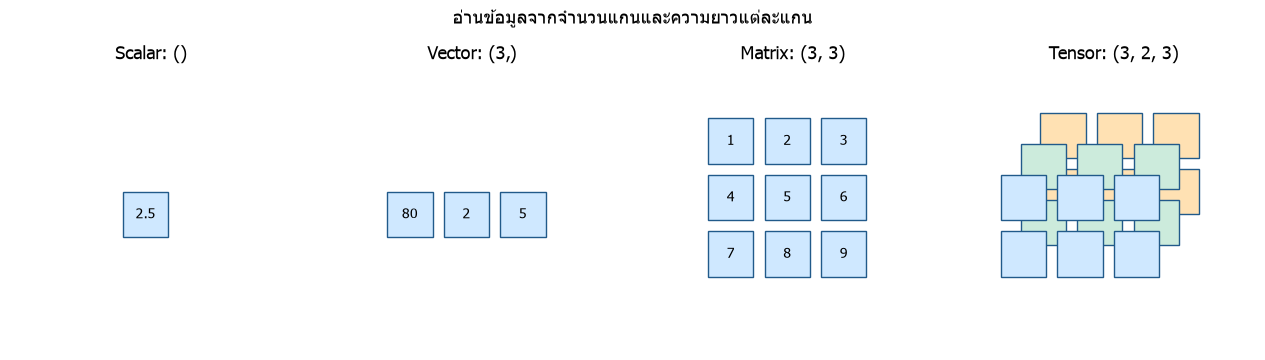

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3.5))
for ax in axes:
    ax.set_xlim(-0.5, 4.5)
    ax.set_ylim(-0.5, 4.5)
    ax.set_aspect("equal")
    ax.axis("off")


def tile(ax, x, y, text="", color="#cfe8ff"):
    ax.add_patch(Rectangle((x, y), 0.8, 0.8, facecolor=color, edgecolor="#215a8a"))
    ax.text(x + 0.4, y + 0.4, text, ha="center", va="center", fontsize=10)


tile(axes[0], 1.5, 1.5, "2.5")
for j, value in enumerate([80, 2, 5]):
    tile(axes[1], j + 0.5, 1.5, str(value))
for i in range(3):
    for j in range(3):
        tile(axes[2], j + 0.5, 2.8 - i, str(i * 3 + j + 1))
for layer, color in reversed(list(enumerate(["#cfe8ff", "#ccebdc", "#ffe1b3"]))):
    for i in range(2):
        for j in range(3):
            tile(axes[3], j + layer * 0.35, 1.8 - i + layer * 0.55, color=color)
for ax, title in zip(axes, ["Scalar: ()", "Vector: (3,)", "Matrix: (3, 3)", "Tensor: (3, 2, 3)"]):
    ax.set_title(title)
fig.suptitle(label("อ่านข้อมูลจากจำนวนแกนและความยาวแต่ละแกน", "Axes and shape"), y=1.02)
plt.tight_layout()
plt.show()

**อ่านภาพ:** รูปสุดท้ายแสดง 3 ชั้น แต่ละชั้นมี 2 แถว × 3 คอลัมน์ จึงกำหนดแกนเป็น
`(layer, row, column) = (3, 2, 3)` ความหมายแกนเป็นสิ่งที่เราออกแบบ ไม่ได้ติดมากับตัวเลขเอง

## 3. Vector คือข้อมูลหนึ่งตัวอย่าง

บ้านหนึ่งหลังอาจเขียนเป็น $x = [80, 2, 5]$ โดยเรียงเป็น
`[พื้นที่ตารางเมตร, จำนวนห้องนอน, อายุปี]` ตัวเลขทั้งสามมีหน่วยต่างกัน
จึงยังไม่ควรนำความยาว vector นี้ไปตีความเป็น “ขนาดบ้าน” โดยตรง

ตัวอย่างในงาน ML: คุณลักษณะลูกค้าหนึ่งคน, ค่าจากเซนเซอร์หนึ่งเวลา หรือ embedding ของข้อความหนึ่งชิ้น
ลำดับคุณลักษณะต้องเหมือนกันตอนฝึกและตอนทำนาย

In [4]:
x = np.array([80, 2, 5], dtype=np.float64)
feature_names = ["area_m2", "bedrooms", "age_years"]
display(pd.Series(x, index=feature_names, name="บ้าน A"))
print("พื้นที่:", x[0], "ตารางเมตร")
print("สองคุณลักษณะแรก:", x[:2])
print("array + array:", x + x)
print("list + list:", [80, 2, 5] + [80, 2, 5])

area_m2      80.0
bedrooms      2.0
age_years     5.0
Name: บ้าน A, dtype: float64

พื้นที่: 80.0 ตารางเมตร
สองคุณลักษณะแรก: [80.  2.]
array + array: [160.   4.  10.]
list + list: [80, 2, 5, 80, 2, 5]


### มอง vector เป็นลูกศร: บวกและคูณด้วย scalar

เพื่อวาดภาพได้ง่าย ใช้ vector 2 องค์ประกอบในระบบพิกัดเดียวกัน:
$u = [3,1]$, $v = [1,2]$ จึงได้ $u+v=[4,3]$ และ $2u=[6,2]$
การบวกทำทีละองค์ประกอบ ส่วนการคูณด้วย scalar เปลี่ยนความยาว
scalar ติดลบจะกลับทิศทางด้วย

u + v = [4. 3.] ; 2u = [6. 2.]


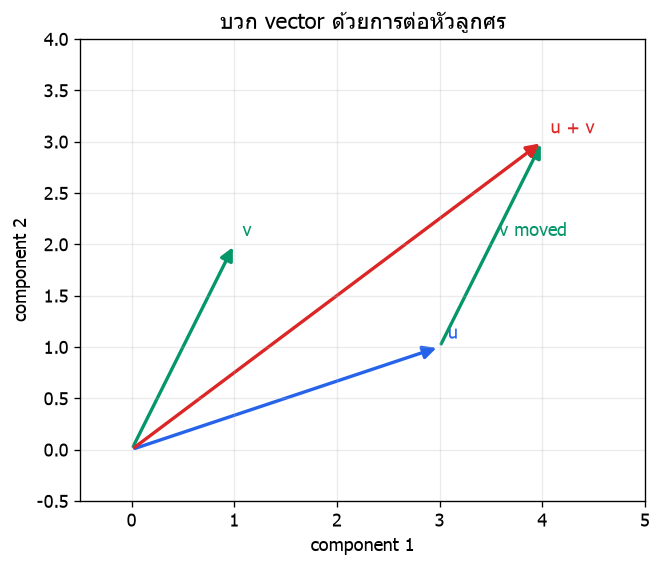

In [5]:
u = np.array([3.0, 1.0])
v = np.array([1.0, 2.0])
print("u + v =", u + v, "; 2u =", 2 * u)
fig, ax = plt.subplots(figsize=(7, 5))
for start, end, color, name in [
    ([0, 0], u, "#2563eb", "u"),
    ([0, 0], v, "#059669", "v"),
    (u, u + v, "#059669", "v moved"),
    ([0, 0], u + v, "#dc2626", "u + v"),
]:
    ax.add_patch(
        FancyArrowPatch(start, end, arrowstyle="-|>", mutation_scale=16, linewidth=2, color=color)
    )
    text_position = (np.asarray(start) + np.asarray(end)) / 2 if name == "v moved" else end
    ax.text(text_position[0] + 0.08, text_position[1] + 0.08, name, color=color)
ax.set(xlim=(-0.5, 5), ylim=(-0.5, 4), xlabel="component 1", ylabel="component 2")
ax.set_aspect("equal")
ax.grid(alpha=0.25)
ax.set_title(label("บวก vector ด้วยการต่อหัวลูกศร", "Vector addition"))
plt.show()

## 4. Matrix คือข้อมูลหลายตัวอย่าง

กำหนด $X \in \mathbb{R}^{n \times d}$ โดย $n$ = จำนวนตัวอย่าง และ $d$ = จำนวนคุณลักษณะ
ในบทเรียนนี้ **แถว = บ้าน**, **คอลัมน์ = feature** และเก็บราคาจริงแยกใน `y`
ไม่ใส่คำตอบลงใน `X` เพราะจะทำให้ข้อมูลเป้าหมายรั่วเข้าโมเดล (target leakage)

เมทริกซ์เป็นตารางสี่เหลี่ยมที่ทุกแถวมีจำนวนคอลัมน์เท่ากัน
อ้างอิงพื้นฐาน: [Matrix (mathematics)](https://en.wikipedia.org/wiki/Matrix_(mathematics))

,area_m2,bedrooms,age_years,price_million_thb
A,80,2,5,2.7
B,120,3,2,4.1
C,60,1,10,1.8
D,150,4,1,5.2


X: (4, 3) → บ้าน 4 หลัง × 3 features
y: (4,) → ราคา 4 ค่า หน่วยล้านบาท


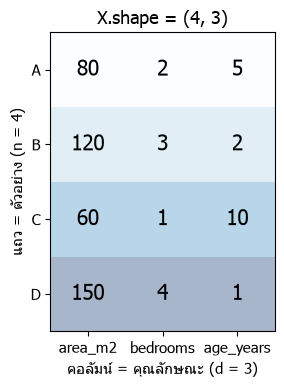

In [6]:
homes = pd.DataFrame(
    {
        "area_m2": [80, 120, 60, 150],
        "bedrooms": [2, 3, 1, 4],
        "age_years": [5, 2, 10, 1],
        "price_million_thb": [2.7, 4.1, 1.8, 5.2],
    },
    index=["A", "B", "C", "D"],
)
X = homes[feature_names].to_numpy(dtype=float)
y = homes["price_million_thb"].to_numpy()
display(homes)
print("X:", X.shape, "→ บ้าน 4 หลัง × 3 features")
print("y:", y.shape, "→ ราคา 4 ค่า หน่วยล้านบาท")
assert X.shape[0] == y.shape[0]

fig, ax = plt.subplots(figsize=(7, 4))
# สีแบ่งแถวเพื่อระบุตัวอย่าง ไม่ใช้สีเทียบขนาดค่าที่มีหน่วยต่างกัน
ax.imshow(np.arange(len(X))[:, None] * np.ones_like(X), cmap="Blues", alpha=0.35)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        ax.text(j, i, f"{X[i, j]:g}", ha="center", va="center", fontsize=15)
ax.set_xticks(range(3), feature_names)
ax.set_yticks(range(4), homes.index)
ax.set_xlabel(label("คอลัมน์ = คุณลักษณะ (d = 3)", "Columns = features (d = 3)"))
ax.set_ylabel(label("แถว = ตัวอย่าง (n = 4)", "Rows = samples (n = 4)"))
ax.set_title("X.shape = (4, 3)")
plt.tight_layout()
plt.show()

## 5. Indexing, shape และ transpose — จุดที่ผิดบ่อย

NumPy เริ่มนับ index จาก 0; `X[1, 0]` คือพื้นที่บ้าน B
`X[0]` จะลดแกนเหลือ `(3,)` แต่ `X[0:1]` คงรูป `(1, 3)`

vector 1 แกน `(3,)` **ยังไม่ได้ระบุว่าเป็นแถวหรือคอลัมน์** และ `x.T` ไม่เปลี่ยน shape
หากต้องการ row vector ใช้ `x[None, :]`; column vector ใช้ `x[:, None]`
ส่วน matrix `X.T` สลับแกนแถวกับคอลัมน์

อ่านพฤติกรรม array เพิ่มเติม: [NumPy basics](https://numpy.org/doc/stable/user/absolute_beginners.html)

In [7]:
print("พื้นที่บ้าน B:", X[1, 0])
for name, value in {
    "X[0]": X[0],
    "X[0:1]": X[0:1],
    "X[:, 0]": X[:, 0],
    "X[:, [0]]": X[:, [0]],
    "x": x,
    "x.T": x.T,
    "x[None, :]": x[None, :],
    "x[:, None]": x[:, None],
    "X.T": X.T,
}.items():
    print(f"{name:14s} shape = {value.shape}")
assert X[0:1].shape == (1, 3)
assert np.array_equal(X.T.T, X)
# Slice มักเป็น view; copy เมื่อต้องการแก้สำเนาโดยไม่กระทบต้นฉบับ
first_home_copy = X[0].copy()
first_home_copy[0] = 999
assert X[0, 0] == 80

พื้นที่บ้าน B: 120.0
X[0]           shape = (3,)
X[0:1]         shape = (1, 3)
X[:, 0]        shape = (4,)
X[:, [0]]      shape = (4, 1)
x              shape = (3,)
x.T            shape = (3,)
x[None, :]     shape = (1, 3)
x[:, None]     shape = (3, 1)
X.T            shape = (3, 4)


## 6. Dot product: ผลรวมถ่วงน้ำหนัก

$$x \cdot w = \sum_{j=1}^{d} x_j w_j$$

**Use case — ทำนายราคาบ้านหนึ่งหลัง:** กำหนดน้ำหนักด้วยมือเพื่อดูวิธีคำนวณ
`w = [0.025, 0.3, -0.02]` และ bias `b = 0.4` หน่วยผลลัพธ์เป็นล้านบาท
น้ำหนักแต่ละตัวแปลงหน่วยของ feature ให้เป็นหน่วยราคา

$$\hat y = 80(0.025) + 2(0.3) + 5(-0.02) + 0.4 = 2.9$$

ค่าชุดนี้เป็น **ตัวอย่างที่กำหนดเอง ยังไม่ได้เรียนรู้จากข้อมูล**
เริ่มด้วย loop แล้วเปรียบเทียบกับ NumPy

In [8]:
w = np.array([0.025, 0.3, -0.02])
b = 0.4
manual_dot = 0.0
for j in range(len(x)):
    manual_dot += x[j] * w[j]

numpy_dot = x @ w
print("แต่ละ feature มีส่วนต่อราคา:", x * w)
print("dot product จาก loop:", manual_dot)
print("dot product จาก NumPy:", numpy_dot)
print("ราคาทำนายรวม bias:", numpy_dot + b, "ล้านบาท")
assert np.isclose(manual_dot, numpy_dot)
assert np.isclose(numpy_dot + b, 2.9)

แต่ละ feature มีส่วนต่อราคา: [ 2.   0.6 -0.1]
dot product จาก loop: 2.5
dot product จาก NumPy: 2.5
ราคาทำนายรวม bias: 2.9 ล้านบาท


## 7. Matrix multiplication: ทำนายทั้ง batch

คูณ matrix ต้องให้ **จำนวนคอลัมน์ตัวซ้าย = จำนวนแถวตัวขวา**

$$A_{m \times k} B_{k \times p} = C_{m \times p},
\qquad C_{ij} = \sum_{r=1}^{k} A_{ir}B_{rj}$$

สำหรับข้อมูลบ้าน: `X (4,3) @ w (3,) → prediction (4,)`
ถ้าเขียน `w` เป็น `(3,1)` จะได้ผล `(4,1)`

**`*` คูณตำแหน่งต่อตำแหน่ง; `@` คูณเมทริกซ์** และโดยทั่วไป `A @ B` ไม่เท่ากับ `B @ A`
อ่านกฎเพิ่มเติม: [NumPy matmul](https://numpy.org/doc/stable/reference/generated/numpy.matmul.html)

In [9]:
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])
print("A * B:\n", A * B)
print("A @ B:\n", A @ B)
print("B @ A:\n", B @ A)
assert (A @ B)[0, 0] == 1 * 5 + 2 * 7

predictions = X @ w + b
loop_predictions = np.array([sum(row[j] * w[j] for j in range(3)) + b for row in X])
np.testing.assert_allclose(predictions, loop_predictions)
display(homes.assign(prediction_million_thb=predictions))
print("เมื่อใช้ column vector:", (X @ w[:, None]).shape)

A * B:
 [[ 5 12]
 [21 32]]
A @ B:
 [[19 22]
 [43 50]]
B @ A:
 [[23 34]
 [31 46]]


,area_m2,bedrooms,age_years,price_million_thb,prediction_million_thb
A,80,2,5,2.7,2.90
B,120,3,2,4.1,4.26
C,60,1,10,1.8,2.00
D,150,4,1,5.2,5.33


เมื่อใช้ column vector: (4, 1)


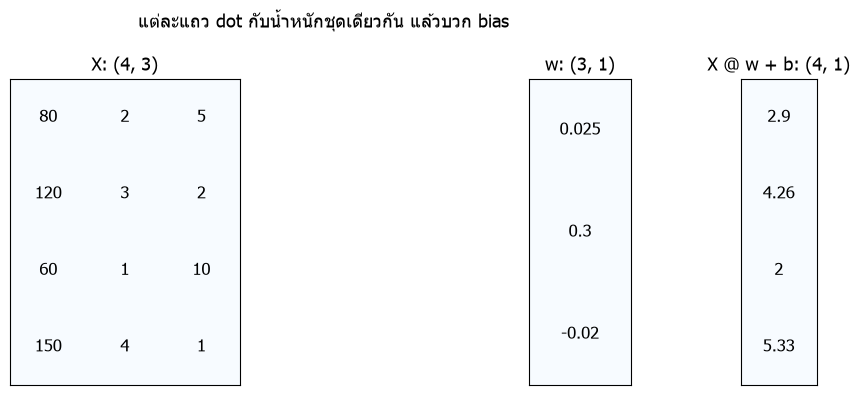

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), gridspec_kw={"width_ratios": [3, 1, 1]})
for ax, values, title in zip(
    axes, [X, w[:, None], predictions[:, None]], ["X: (4, 3)", "w: (3, 1)", "X @ w + b: (4, 1)"]
):
    ax.imshow(np.zeros_like(values), cmap="Blues", vmin=0, vmax=1)
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            ax.text(j, i, f"{values[i, j]:g}", ha="center", va="center", fontsize=12)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle(
    label(
        "แต่ละแถว dot กับน้ำหนักชุดเดียวกัน แล้วบวก bias", "Each row uses the same weights, then adds bias"
    )
)
plt.tight_layout()
plt.show()

## 8. Norm และ cosine similarity

L2 norm คือความยาว $\|u\|_2=\sqrt{\sum_j u_j^2}$
Euclidean distance คือ $\|u-v\|_2$ ส่วน cosine similarity เปรียบเทียบทิศทาง:

$$\cos(u,v) = \frac{u \cdot v}{\|u\|_2\|v\|_2}$$

สำหรับ vector จริงที่ไม่เป็นศูนย์ cosine อยู่ระหว่าง −1 และ 1
ค่าบวกใกล้ 1 หมายถึงทิศใกล้กัน **ไม่ได้เป็นความน่าจะเป็น**
ถ้ามี zero vector นิยามนี้หารด้วยศูนย์ ต้องกำหนดวิธีจัดการก่อน

**Use case — ค้นหาบทเรียนที่ใกล้ความสนใจ:** สร้าง vector คะแนน 3 หัวข้อ
`[Python, statistics, deep_learning]` ด้วยมือเพื่ออธิบายกลไก
นี่ไม่ใช่ embedding ที่ได้จากโมเดลภาษา

,lesson,cosine,distance
0,Python for data,0.999861,0.141421
2,Python basics,0.843482,0.734847
3,Statistics,0.767335,0.824621
1,Neural networks,0.273505,1.407125


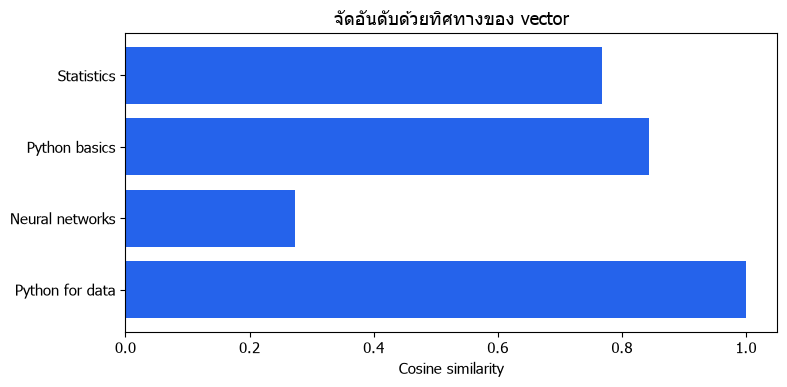

In [11]:
query = np.array([1.0, 0.8, 0.1])
lessons = np.array([[0.9, 0.7, 0.1], [0.1, 0.2, 1.0], [0.8, 0.1, 0.2], [0.2, 1.0, 0.1]])
names = ["Python for data", "Neural networks", "Python basics", "Statistics"]
query_norm = np.linalg.norm(query)
lesson_norms = np.linalg.norm(lessons, axis=1)
assert query_norm > 0 and np.all(lesson_norms > 0)
cosine_scores = (lessons @ query) / (lesson_norms * query_norm)
distances = np.linalg.norm(lessons - query, axis=1)
ranking = pd.DataFrame({"lesson": names, "cosine": cosine_scores, "distance": distances})
display(ranking.sort_values("cosine", ascending=False))
assert np.isclose(np.linalg.norm([3.0, 4.0]), 5)
np.testing.assert_allclose(
    cosine_scores, (lessons @ (query * 10)) / (lesson_norms * np.linalg.norm(query * 10))
)
fig, ax = plt.subplots()
ax.barh(names, cosine_scores, color="#2563eb")
ax.set(xlim=(0, 1.05), xlabel="Cosine similarity")
ax.set_title(label("จัดอันดับด้วยทิศทางของ vector", "Ranking by vector direction"))
plt.tight_layout()
plt.show()

## 9. Axis และ broadcasting: ปรับข้อมูลหลายแถวพร้อมกัน

`axis` ระบุแกนที่นำสมาชิกมารวมกัน เช่น `X.mean(axis=0)` รวมข้ามบ้านแต่ละหลัง
จึงเหลือค่าเฉลี่ย **ต่อ feature** ขณะที่ `X.mean(axis=1)` รวม features ของบ้านแต่ละหลัง
ซึ่งในตัวอย่างนี้มีหน่วยต่างกัน จึงไม่มีความหมายทางธุรกิจที่ชัดเจน

**Broadcasting** อนุญาตให้คำนวณกับ shape ที่ต่างกัน โดยเทียบจากแกนขวาสุด:
แต่ละคู่ต้องมีขนาดเท่ากัน หรืออย่างน้อยข้างหนึ่งมีขนาด 1

```text
X                  (4, 3)
mean               (1, 3)
X - mean           (4, 3)   ← หักค่าเฉลี่ยแต่ละ feature จากทุกแถว
```

**Use case — standardization:** $z_{ij}=(x_{ij}-\mu_j)/\sigma_j$
ช่วยให้ระยะทางไม่ถูกครอบงำด้วย feature ที่มีช่วงค่ามาก
ต้องหา mean/std จาก **training set เท่านั้น** แล้วใช้ค่าเดิมกับ validation/test
ถ้าคอลัมน์คงที่ std เป็น 0 ให้ใช้ตัวหาร 1 เพื่อหลีกเลี่ยงการหารศูนย์

เอกสารอ้างอิง: [NumPy broadcasting](https://numpy.org/doc/stable/user/basics.broadcasting.html)

In [12]:
# ในตัวอย่างนี้ถือบ้าน A–C เป็น training และบ้าน D เป็น test
X_train_demo = X[:3]
X_test_demo = X[3:]
mean = X_train_demo.mean(axis=0, keepdims=True)
std = X_train_demo.std(axis=0, keepdims=True)  # ddof=0
safe_std = np.where(std == 0, 1.0, std)
Z_train_demo = (X_train_demo - mean) / safe_std
Z_test_demo = (X_test_demo - mean) / safe_std
print("mean shape:", mean.shape, "; std shape:", std.shape)
display(pd.DataFrame(Z_train_demo, columns=feature_names, index=homes.index[:3]))
print("ค่าเฉลี่ยหลังปรับสเกล (training):", Z_train_demo.mean(axis=0))
print("test ที่ใช้ค่า mean/std จาก training:", Z_test_demo)
np.testing.assert_allclose(Z_train_demo.mean(axis=0), 0, atol=1e-12)
np.testing.assert_allclose(Z_train_demo.std(axis=0), 1)

# ปรับสเกลแต่ละตัวอย่างด้วย factor ต่างกัน ต้องเพิ่มแกนคอลัมน์
row_factors = np.array([1.0, 2.0, 3.0, 4.0])
print("row_factors[:, None].shape:", row_factors[:, None].shape)
print("ผลลัพธ์ shape:", (X * row_factors[:, None]).shape)

mean shape: (1, 3) ; std shape: (1, 3)


,area_m2,bedrooms,age_years
A,-0.267261,0.000000,-0.202031
B,1.336306,1.224745,-1.111168
C,-1.069045,-1.224745,1.313198


ค่าเฉลี่ยหลังปรับสเกล (training): [-0.  0. -0.]
test ที่ใช้ค่า mean/std จาก training: [[ 2.539  2.449 -1.414]]
row_factors[:, None].shape: (4, 1)
ผลลัพธ์ shape: (4, 3)


## 10. อ่านข้อผิดพลาดจาก shape และป้องกัน silent bug

ข้อผิดพลาดบางอย่างทำให้โปรแกรมหยุดทันที แต่บางอย่างยังคำนวณต่อได้แล้วให้ผลที่ผิดโจทย์
ตัวอย่างสำคัญคือ prediction `(n,1)` ลบ target `(n,)` จะ broadcast เป็น `(n,n)`
แทนที่จะได้ความคลาดเคลื่อนหนึ่งค่าต่อตัวอย่าง

เซลล์ต่อไป **ตั้งใจทำให้เกิดข้อผิดพลาด** แต่ใช้ `try/except` จับไว้ จึงยัง Run All ได้

In [13]:
try:
    X @ np.ones(2)
except ValueError as error:
    print("คูณไม่ได้: X มี 3 features แต่น้ำหนักมี 2 ค่า")
    print(type(error).__name__, str(error).splitlines()[0])

try:
    X + np.ones(4)
except ValueError:
    print("broadcast ไม่ได้: แกนขวาสุดมีขนาด 3 กับ 4")

pred_column = predictions[:, None]
wrong_residual = pred_column - y
correct_residual = predictions - y
print("ผิดโจทย์แต่ไม่ error:", wrong_residual.shape)
print("ถูกต้อง:", correct_residual.shape)
assert predictions.shape == y.shape
assert correct_residual.shape == (4,)
print("MSE ของน้ำหนักที่กำหนดด้วยมือ:", np.mean(correct_residual**2))

คูณไม่ได้: X มี 3 features แต่น้ำหนักมี 2 ค่า
ValueError matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 3)
broadcast ไม่ได้: แกนขวาสุดมีขนาด 3 กับ 4
ผิดโจทย์แต่ไม่ error: (4, 4)
ถูกต้อง: (4,)
MSE ของน้ำหนักที่กำหนดด้วยมือ: 0.03062500000000003


## 11. Matrix เป็นการแปลงพิกัด: scale และ rotation

นอกจากเก็บข้อมูล matrix ยังแทน **linear transformation** ได้
ใช้ convention เวกเตอร์คอลัมน์ $x'=Rx$; ถ้าเก็บจุดเป็นแถวแบบ dataset ให้เขียน `points @ R.T`

**Use case:** ทำความเข้าใจการหมุนพิกัด การปรับข้อมูลภาพ และการแปลง features
ตัวอย่างนี้แปลงจุดพิกัดเท่านั้น การหมุนภาพจริงยังต้องจัดการ sampling/interpolation ของพิกเซล

การเลื่อนทุกจุดด้วย bias เป็น **affine transformation**: $x'=Rx+b$
โดยทั่วไปไม่ใช่ linear transformation เพราะจุดศูนย์ถูกเลื่อนไปที่ $b$

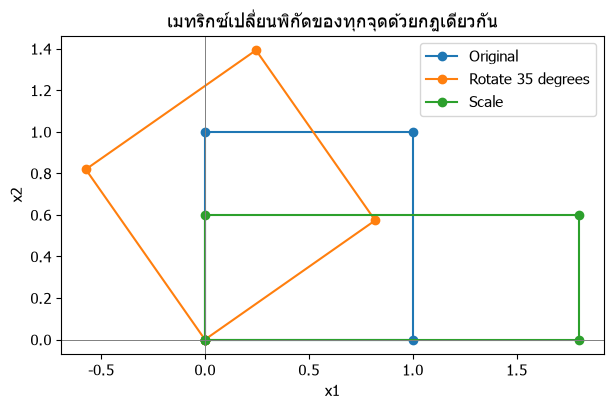

In [14]:
points = np.array([[0, 0], [1, 0], [1, 1], [0, 1], [0, 0]], dtype=float)
angle = np.deg2rad(35)
R = np.array([[np.cos(angle), -np.sin(angle)], [np.sin(angle), np.cos(angle)]])
S = np.diag([1.8, 0.6])
rotated = points @ R.T
scaled = points @ S.T
np.testing.assert_allclose(R.T @ R, np.eye(2), atol=1e-12)
np.testing.assert_allclose(np.linalg.norm(rotated, axis=1), np.linalg.norm(points, axis=1))
fig, ax = plt.subplots(figsize=(7, 5))
for values, name in [(points, "Original"), (rotated, "Rotate 35 degrees"), (scaled, "Scale")]:
    ax.plot(values[:, 0], values[:, 1], "o-", label=name)
ax.axhline(0, color="gray", linewidth=0.7)
ax.axvline(0, color="gray", linewidth=0.7)
ax.set_aspect("equal")
ax.legend()
ax.set_title(label("เมทริกซ์เปลี่ยนพิกัดของทุกจุดด้วยกฎเดียวกัน", "Matrix transformations"))
ax.set(xlabel="x1", ylabel="x2")
plt.show()

## 12. Mini-project: เรียนรู้น้ำหนักเพื่อทำนายราคาบ้าน

ก่อนหน้านี้กำหนด `w` ด้วยมือ คราวนี้ให้ข้อมูลช่วยหาน้ำหนัก
สร้างบ้านจำลอง 240 หลังด้วย seed เดิม แบ่ง train/test ก่อนฝึก

สมการสำหรับทั้งชุดข้อมูล:

$$\hat y = Xw+b, \qquad
\mathrm{MSE}=\frac{1}{n}\sum_{i=1}^{n}(\hat y_i-y_i)^2$$

เพิ่มคอลัมน์ 1 เพื่อรวม bias เข้าเวกเตอร์น้ำหนัก:

$$X_{aug} = [\mathbf{1}, X], \qquad
\theta=[b,w_1,w_2,w_3]^T, \qquad \hat y=X_{aug}\theta$$

**ขั้นตอน A — สร้างข้อมูล:** ราคาเป็นล้านบาท มี noise จำลอง
ความสัมพันธ์เป็นเส้นตรงโดยตั้งใจ ผลดีบนข้อมูลนี้ไม่ได้แปลว่าจะทำนายตลาดจริงได้ดี

In [15]:
rng = np.random.default_rng(SEED)
X_all = np.column_stack(
    [
        rng.uniform(40, 200, 240),
        rng.integers(1, 6, 240),
        rng.integers(0, 31, 240),
    ]
)
true_w = np.array([0.025, 0.30, -0.020])
true_b = 0.4
y_all = X_all @ true_w + true_b + rng.normal(0, 0.12, 240)
order = rng.permutation(len(X_all))
train_idx, test_idx = order[:180], order[180:]
X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]
display(pd.DataFrame(X_all[:5], columns=feature_names).assign(price_million_thb=y_all[:5]))
print("train:", X_train.shape, y_train.shape)
print("test:", X_test.shape, y_test.shape)
assert set(train_idx).isdisjoint(test_idx)

,area_m2,bedrooms,age_years,price_million_thb
0,163.832968,2.0,4.0,4.915820
1,110.220550,5.0,28.0,3.904766
2,177.375667,2.0,26.0,4.665634
3,151.578885,4.0,3.0,5.195386
4,55.068376,3.0,24.0,2.141668


train: (180, 3) (180,)
test: (60, 3) (60,)


**ขั้นตอน B — fit ด้วย least squares ของ NumPy:** หา $\theta$ ที่ทำให้
$\|X_{aug}\theta-y\|_2^2$ ต่ำที่สุด ใช้ `np.linalg.lstsq`
ไม่จำเป็นต้องสร้าง inverse ของ $X^TX$ ซึ่งอาจ singular หรือมีความคลาดเคลื่อนเชิงตัวเลขมาก

`lstsq` ยังคืน residuals, matrix rank และ singular values เราจะใช้ rank ตรวจว่าคอลัมน์เป็นอิสระกันครบหรือไม่
หัวข้อนี้จะเรียนลึกขึ้นใน notebook เรื่อง eigenvalues/SVD
อ้างอิง: [NumPy lstsq](https://numpy.org/doc/stable/reference/generated/numpy.linalg.lstsq.html)

In [16]:
X_train_aug = np.column_stack([np.ones(len(X_train)), X_train])
X_test_aug = np.column_stack([np.ones(len(X_test)), X_test])
theta, residuals, design_rank, singular_values = np.linalg.lstsq(X_train_aug, y_train, rcond=None)
y_pred = X_test_aug @ theta
print("design matrix shape:", X_train_aug.shape, "; matrix rank:", design_rank)
display(
    pd.DataFrame(
        {"parameter": ["bias", *feature_names], "true": np.r_[true_b, true_w], "learned": theta}
    )
)
assert y_pred.shape == y_test.shape
print("ค่าที่เรียนรู้ใกล้ค่าจริง แต่ไม่จำเป็นต้องตรงกัน เพราะมี noise")

design matrix shape: (180, 4) ; matrix rank: 4


,parameter,true,learned
0,bias,0.400,0.383307
1,area_m2,0.025,0.025299
2,bedrooms,0.300,0.290887
3,age_years,-0.020,-0.020111


ค่าที่เรียนรู้ใกล้ค่าจริง แต่ไม่จำเป็นต้องตรงกัน เพราะมี noise


**ขั้นตอน C — ประเมินและเทียบไลบรารี:** วัด MAE หน่วยล้านบาทบน test set
เปรียบเทียบกับ baseline ที่ทายค่าเฉลี่ยราคาของ training ทุกครั้ง
จากนั้นตรวจว่า scikit-learn ได้คำทำนายสอดคล้องกับ NumPy
กราฟที่จุดอยู่ใกล้เส้นทแยงแสดงว่าราคาทำนายใกล้ราคาจำลองจริง

MAE ของโมเดล: 0.096 ล้านบาท ≈ 96,041 บาท
MAE ของ baseline: 1.110 ล้านบาท
NumPy และ scikit-learn ให้ผลสอดคล้องกัน


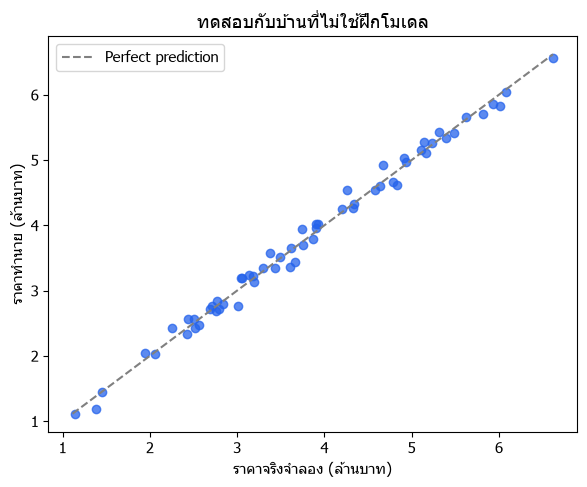

In [17]:
mae = np.mean(np.abs(y_pred - y_test))
baseline_mae = np.mean(np.abs(y_train.mean() - y_test))
print(f"MAE ของโมเดล: {mae:.3f} ล้านบาท ≈ {mae * 1_000_000:,.0f} บาท")
print(f"MAE ของ baseline: {baseline_mae:.3f} ล้านบาท")
sklearn_model = LinearRegression().fit(X_train, y_train)
np.testing.assert_allclose(y_pred, sklearn_model.predict(X_test), rtol=1e-9, atol=1e-9)
print("NumPy และ scikit-learn ให้ผลสอดคล้องกัน")
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_test, y_pred, alpha=0.75, color="#2563eb")
limits = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(limits, limits, "--", color="gray", label="Perfect prediction")
ax.set_xlabel(label("ราคาจริงจำลอง (ล้านบาท)", "Synthetic actual price (million THB)"))
ax.set_ylabel(label("ราคาทำนาย (ล้านบาท)", "Predicted price (million THB)"))
ax.set_title(label("ทดสอบกับบ้านที่ไม่ใช้ฝึกโมเดล", "Held-out test predictions"))
ax.legend()
plt.tight_layout()
plt.show()

### เสริม: จำนวนแกนไม่ใช่ matrix rank

`ndim` นับแกนของ array แต่ **matrix rank** นับจำนวนแถว/คอลัมน์ที่เป็นอิสระเชิงเส้น
matrix 2 แกนจึงไม่ได้มี rank เท่ากับ 2 เสมอไป
บางแหล่งใช้คำว่า “tensor rank” หมายถึงจำนวนแกนในบริบทซอฟต์แวร์ แต่ในคณิตศาสตร์คำนี้ยังมีนิยามอื่น
จึงควรใช้คำว่า `ndim` หรือ “จำนวนแกน” เมื่ออธิบาย array

**Use case:** ถ้าคอลัมน์ feature หนึ่งเป็นสองเท่าของอีกคอลัมน์ จะมีข้อมูลซ้ำกัน
น้ำหนักแต่ละตัวอาจระบุได้ไม่เป็นเอกลักษณ์ แม้ยังทำนายได้

In [18]:
dependent = np.array([[1.0, 2.0], [2.0, 4.0], [3.0, 6.0]])
print("shape:", dependent.shape)
print("ndim:", dependent.ndim)
print("matrix rank:", np.linalg.matrix_rank(dependent))
assert dependent.ndim == 2 and np.linalg.matrix_rank(dependent) == 1
print("คอลัมน์ที่ 2 เป็นสองเท่าของคอลัมน์ที่ 1:", np.allclose(dependent[:, 1], 2 * dependent[:, 0]))

shape: (3, 2)
ndim: 2
matrix rank: 1
คอลัมน์ที่ 2 เป็นสองเท่าของคอลัมน์ที่ 1: True


## 13. Neural network หนึ่งชั้นก็เริ่มจาก matrix multiplication

ถ้าอินพุตหนึ่งตัวอย่างมี 3 features และชั้นถัดไปมี 4 units:

```text
input                weights          bias              output
(batch, 3)     @      (3, 4)     +     (4,)       →      (batch, 4)
```

$$H=\mathrm{ReLU}(ZW+b), \qquad \mathrm{ReLU}(t)=\max(0,t)$$

คอลัมน์แต่ละคอลัมน์ของ `W` เป็นชุดน้ำหนักของหนึ่ง unit
bias ถูก broadcast ไปทุกตัวอย่าง ก่อนผ่านฟังก์ชันไม่เชิงเส้น
**ตัวอย่างนี้เป็น forward pass ด้วยน้ำหนักสุ่ม ยังไม่ได้ฝึก neural network**

In [19]:
rng = np.random.default_rng(SEED)
train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0)
Z_small = (X_test[:5] - train_mean) / np.where(train_std == 0, 1, train_std)
W = rng.normal(0, 0.3, size=(3, 4))
b_hidden = np.zeros(4)
pre_activation = Z_small @ W + b_hidden
H = np.maximum(0, pre_activation)
print("input:", Z_small.shape, "weights:", W.shape, "bias:", b_hidden.shape, "output:", H.shape)
display(pd.DataFrame(H, columns=[f"unit_{i}" for i in range(4)]))
assert H.shape == (5, 4) and np.all(H >= 0)

input: (5, 3) weights: (3, 4) bias: (4,) output: (5, 4)


,unit_0,unit_1,unit_2,unit_3
0,0.000000,0.000000,0.033593,0.000000
1,0.471833,0.206103,0.112570,0.192245
2,0.842474,0.855709,0.000000,0.000000
3,0.558516,0.414147,0.000000,0.000605
4,0.529792,0.000000,0.375225,0.479194


## 14. Tensor ใน Computer Vision: ภาพสีและ batch

ภาพ grayscale เก็บได้เป็น matrix `(height, width)` ส่วนภาพ RGB ใน convention นี้เป็น
`(height, width, channels)` โดยแกนสุดท้ายเรียง Red, Green, Blue
หลายภาพรวมกันเป็น `(batch, height, width, channels)` หรือ **NHWC**

บางระบบใช้ **NCHW** จึงต้องอ่านสัญญาการจัดแกนของ API ที่ใช้อยู่
การสลับแกนต้องใช้ `transpose`; `reshape` เพียงจัดข้อมูลตามลำดับใหม่ ไม่ได้ย้ายความหมายแกนให้เอง

**Use case:** เตรียมภาพก่อนส่งเข้าโมเดล และตรวจว่าช่องสี/แกน batch ถูกต้อง
ตัวอย่างสร้างภาพเอง ไม่ต้องโหลดไฟล์ภายนอก

หนึ่งภาพ HWC: (8, 8, 3)
หลายภาพ NHWC: (2, 8, 8, 3)
สลับแกนเป็น NCHW: (2, 3, 8, 8)
flatten สำหรับ MLP: (2, 192)


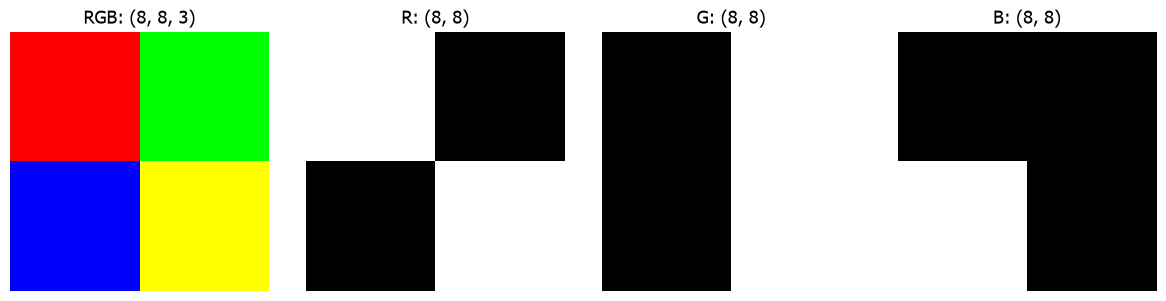

In [20]:
height, width = 8, 8
rgb = np.zeros((height, width, 3), dtype=np.float32)
rgb[:4, :4, 0] = 1.0  # มุมซ้ายบนสีแดง
rgb[:4, 4:, 1] = 1.0  # มุมขวาบนสีเขียว
rgb[4:, :4, 2] = 1.0  # มุมซ้ายล่างสีน้ำเงิน
rgb[4:, 4:, :] = [1, 1, 0]  # มุมขวาล่างสีเหลือง
batch_nhwc = np.stack([rgb, np.flip(rgb, axis=1)], axis=0)
batch_nchw = batch_nhwc.transpose(0, 3, 1, 2)
flat_batch = batch_nhwc.reshape(len(batch_nhwc), -1)
print("หนึ่งภาพ HWC:", rgb.shape)
print("หลายภาพ NHWC:", batch_nhwc.shape)
print("สลับแกนเป็น NCHW:", batch_nchw.shape)
print("flatten สำหรับ MLP:", flat_batch.shape)
assert batch_nchw.shape == (2, 3, 8, 8)
np.testing.assert_array_equal(batch_nchw.transpose(0, 2, 3, 1), batch_nhwc)
np.testing.assert_array_equal(flat_batch.reshape(batch_nhwc.shape), batch_nhwc)
# shape ออกมาเหมือน NCHW ก็ยังไม่พอ ต้องตรวจว่าค่าสมาชิกถูกตำแหน่ง
assert not np.array_equal(batch_nhwc.reshape(2, 3, 8, 8), batch_nchw)
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes[0].imshow(rgb)
axes[0].set_title("RGB: (8, 8, 3)")
for channel, name in enumerate(["R", "G", "B"]):
    axes[channel + 1].imshow(rgb[:, :, channel], cmap="gray", vmin=0, vmax=1)
    axes[channel + 1].set_title(f"{name}: (8, 8)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

**อ่านภาพ:** แต่ละช่องสีด้านขวาแสดงด้วย grayscale เพื่อให้อ่านความเข้มได้ชัด
สีขาวหมายถึงช่องนั้นมีค่า 1 และสีดำมีค่า 0 พื้นที่สีเหลืองมี R=1, G=1, B=0
การ flatten คงค่าพิกเซลไว้ แต่ไม่แสดงโครงสร้างเพื่อนบ้านเป็นแกนอย่างเดิม

## 15. แผนที่เชื่อมแนวคิดกับงานจริง

| แนวคิด | โค้ดสำคัญ | ตัวอย่างการใช้งาน |
|---|---|---|
| Feature vector | `x.shape == (d,)` | คุณลักษณะลูกค้าหนึ่งราย |
| Dataset matrix | `X.shape == (n, d)` | ข้อมูลฝึกโมเดลตาราง |
| Dot product | `x @ w` | คะแนนเชิงเส้นของหนึ่งตัวอย่าง |
| Matrix multiplication | `X @ W` | ทำนายหลายตัวอย่าง/หลาย outputs |
| Norm / cosine | `np.linalg.norm` | ระยะห่างและการค้นหาความคล้าย |
| Broadcasting | `(X - mean) / std` | เตรียม features โดยไม่เขียน loop ทีละแถว |
| Least squares | `np.linalg.lstsq` | เรียนรู้น้ำหนัก linear regression |
| Tensor axes | `transpose`, `stack` | จัด batch ภาพหรือข้อมูลตามเวลา |

**ก่อนคำนวณทุกครั้ง:** แต่ละแกนหมายถึงอะไร? หน่วยของแต่ละ feature คืออะไร?
shape ที่คาดหวังคืออะไร? กำลังใช้ข้อมูล test มาช่วย fit โดยไม่ตั้งใจหรือไม่?

## 16. แบบฝึกหัด — ลองก่อนเปิดเฉลย

ใช้ตัวแปรจากบทเรียนด้านบน และเปลี่ยนค่าในเซลล์ทดลองได้

1. สร้างบ้านใหม่ 2 หลัง `[100, 3, 4]` และ `[70, 2, 12]` ให้มี shape `(2,3)`
   ทำนายด้วยน้ำหนัก `w, b` ที่กำหนดด้วยมือในส่วน 6 ควรได้ `[3.72, 2.51]` ล้านบาท
2. หา vector ค่าเฉลี่ย **ต่อ feature** ของบ้านใหม่ทั้งสองหลัง ควรได้ `[85, 2.5, 8]`
3. สร้าง column vector จาก `[1,2,3]` ให้มี shape `(3,1)`
4. ถ้า batch ภาพมี shape `(10,32,32,3)` หลัง flatten ต่อภาพจะเป็นเท่าไร?
5. เปลี่ยน `angle` ในส่วน 11 เป็น 90 องศา คาดเดาพิกัด `[1,0]` หลังหมุนก่อนรัน
6. เพิ่ม noise ใน mini-project จาก `0.12` เป็น `0.60` แล้วรันส่วน 12 ใหม่ทั้งหมด
   จด MAE ของโมเดลและ baseline โดยรักษา seed และ split เดิม อย่าเลือกโมเดลจาก test ซ้ำไปมาในงานจริง

ตัวแปรที่ลงท้าย `_exercise` แยกจากตัวอย่างหลัก เพื่อทดลองโดยไม่เขียนทับข้อมูลเดิม

In [21]:
# พื้นที่ทดลอง: ลองเขียนโค้ดของคุณเองก่อนเปิดเฉลยด้านล่าง
new_homes_exercise = np.array([[100.0, 3.0, 4.0], [70.0, 2.0, 12.0]])
print("ข้อมูลสำหรับทดลอง:\n", new_homes_exercise)
# เติม: คำทำนาย, ค่าเฉลี่ยต่อ feature และ column vector

ข้อมูลสำหรับทดลอง:
 [[100.   3.   4.]
 [ 70.   2.  12.]]


<details>
<summary>เปิดดูแนวทางเฉลยข้อ 1–5</summary>

```python
pred_exercise = new_homes_exercise @ w + b
np.testing.assert_allclose(pred_exercise, [3.72, 2.51])
mean_exercise = new_homes_exercise.mean(axis=0)
np.testing.assert_allclose(mean_exercise, [85, 2.5, 8])
column_exercise = np.array([1, 2, 3])[:, None]
assert column_exercise.shape == (3, 1)
# ภาพ 10 ภาพ ภาพละ 32 × 32 × 3 ค่า
assert np.zeros((10, 32, 32, 3)).reshape(10, -1).shape == (10, 3072)
# หมุน [1,0] ทวนเข็ม 90 องศา ได้ [0,1] (ยอมให้มี floating-point error)
rotation_90 = np.array([[0., -1.], [1., 0.]])
np.testing.assert_allclose(np.array([1., 0.]) @ rotation_90.T, [0., 1.])
```

ข้อ 6: noise ที่มากขึ้นทำให้คำตอบมีส่วนที่ features อธิบายไม่ได้มากขึ้น
โดยทั่วไป MAE จะสูงขึ้น ให้ใช้ผลที่รันจริงประกอบคำอธิบาย

</details>

### บันทึกความเข้าใจด้วยคำของคุณเอง

- ถ้าเพื่อนถามว่า `(3,)` กับ `(3,1)` ต่างกันอย่างไร ฉันจะตอบว่า…
- ฉันใช้ matrix multiplication แทน loop ในขั้นตอน…
- ข้อผิดพลาดเรื่อง shape ที่ฉันจะตรวจเสมอคือ…
- ในข้อมูลที่ฉันอยากนำมาใช้จริง แถวหมายถึง… คอลัมน์หมายถึง… และ target คือ…

## แหล่งอ้างอิงและขอบเขต

เนื้อหาเรียบเรียงใหม่เป็นบทเรียนเชิงปฏิบัติ โค้ด ข้อมูลจำลอง และภาพทั้งหมดสร้างสำหรับ notebook นี้
ไม่ได้ใช้ภาพจากบทความต้นฉบับ ตรวจสอบแหล่งข้อมูลเมื่อ **16 กันยายน 2026**

แหล่งที่ผู้เรียนระบุ:

1. [Towards Data Science — From Vectors to Tensors: Exploring the Mathematics of Tensor Algebra](https://towardsdatascience.com/what-are-tensors-in-machine-learning-5671814646ff/)
   ใช้เป็นจุดเริ่มต้นเรื่อง scalar/vector/matrix/tensor และการแทนข้อมูล ML;
   บทเรียนแยกความหมาย `shape`, `size`, จำนวนแกน และ matrix rank ให้ชัดขึ้น
2. [Wikipedia — Matrix (mathematics)](https://en.wikipedia.org/wiki/Matrix_(mathematics))
   อ่านต่อเรื่องสัญกรณ์เมทริกซ์ การคูณ และการแปลงเชิงเส้น
3. [E‑magnetica — Scalar, vector, tensor](https://e-magnetica.pl/doku.php/scalar_vector_tensor)
   เก็บไว้เป็นลิงก์อ่านเพิ่มเติมตามที่ผู้เรียนให้มา **ยังไม่ได้ตรวจสอบเนื้อหาบทความ**
   เนื่องจากเว็บแสดงหน้าตรวจสอบการเข้าถึง จึงไม่ได้อ้างข้อเท็จจริงเฉพาะจากหน้านี้

เอกสารปฐมภูมิสำหรับตรวจโค้ด:

- [NumPy — Array fundamentals](https://numpy.org/doc/stable/user/absolute_beginners.html)
- [NumPy — Broadcasting](https://numpy.org/doc/stable/user/basics.broadcasting.html)
- [NumPy — Matrix multiplication](https://numpy.org/doc/stable/reference/generated/numpy.matmul.html)
- [NumPy — Least squares](https://numpy.org/doc/stable/reference/generated/numpy.linalg.lstsq.html)

อ่านต่อในโครงการ: `02_matrix_operations.ipynb` สำหรับการดำเนินการกับเมทริกซ์,
`03_eigenvalues_and_svd.ipynb` สำหรับโครงสร้างเมทริกซ์ และ
`05_linear_regression_numpy.ipynb` สำหรับการต่อยอดโมเดลเชิงเส้น